# final

In [13]:
import pandas as pd
import numpy as np

def generate_review_format(input_filepath, output_filepath):
    # Load the original dataset
    df = pd.read_csv(input_filepath)
    
    # Lowercase and strip all original column names to make matching foolproof
    df.columns = df.columns.str.lower().str.strip()
    
    # 1. Create a new dataframe mapping your CSV columns to the exact requested names
    out_df = pd.DataFrame()
    
    # Explicit Mappings based on your instructions
    out_df['Context'] = df.get('context', df.get('decoded_text', ''))
    out_df['g_time'] = df.get('g_time', '')
    out_df['g_task'] = df.get('ga', df.get('g_task', '')) 
    out_df['Label'] = df.get('label', '')                  
    out_df['Pred.'] = df.get('pred', '')                   
    out_df['Expert Label'] = df.get('real', df.get('expert', '')) 
    out_df['Reason'] = df.get('reason', '')

    # Clean up empty cells (Convert pandas NaN to empty strings)
    out_df = out_df.replace(np.nan, '', regex=True)

    # 2. Write the formatted output to the Markdown file
    with open(output_filepath, 'w', encoding='utf-8') as f:
        
        for index, row in out_df.iterrows():
            # Sanitize text for Markdown (pipes break MD tables)
            context = str(row['Context']).replace('\n', ' ').replace('|', '&#124;')
            g_time = str(row['g_time']).replace('\n', ' ')
            g_task = str(row['g_task']).replace('\n', ' ')
            label = str(row['Label']).replace('\n', ' ').replace('|', '&#124;')
            pred = str(row['Pred.']).replace('\n', ' ').replace('|', '&#124;')
            expert = str(row['Expert Label']).replace('\n', ' ').replace('|', '&#124;')
            reason = str(row['Reason']).replace('\n', ' ').replace('|', '&#124;')

            # Write individual vertical table per row
            f.write("| | |\n")
            f.write("| :--- | :--- |\n")
            f.write(f"| **Context** | {context} |\n")
 
            f.write(f"| **g_task** | {g_task} |\n")
            f.write(f"| **Label** | {label} |\n")
            f.write(f"| **Pred.** | {pred} |\n")
            f.write(f"| **Expert Label** | {expert} |\n")
            f.write(f"| **Reason** | {reason} |\n")
            
            # Add a visual separator between items
            f.write("\n---\n\n")
            
    print(f"Successfully generated Markdown file: {output_filepath}")

# Execute the function for your files
generate_review_format('time.csv', 'time_review_format.md')
generate_review_format('tag.csv', 'tag_review_format.md')

Successfully generated Markdown file: time_review_format.md
Successfully generated Markdown file: tag_review_format.md


In [24]:
def simulate_barista_fire(
    years=30,
    initial_portfolio=500000.0,
    barista_income=25000.0,
    income_increase_rate=0.02, # 2% annual wage growth
    base_expenses=20000.0,     # Groceries, utilities, health insurance, etc.
    inflation_rate=0.03,       # 3% annual inflation
    irr=0.07,                  # 7% nominal investment return
    buy_house=False,           # Toggle to True to simulate buying
    house_price=300000.0,
    down_payment_pct=0.20,
    mortgage_rate=0.05,
    rent_annual=18000.0        # Rent cost if you don't buy
):
    portfolio = initial_portfolio
    data = []
    
    # 1. Initialize Housing Costs
    if buy_house:
        down_payment = house_price * down_payment_pct
        loan_amount = house_price - down_payment
        portfolio -= down_payment # Subtract down payment from investments
        
        # Calculate fixed annual mortgage payment (30-year fixed)
        i = mortgage_rate / 12
        n = 30 * 12
        monthly_mortgage = loan_amount * (i * (1 + i)**n) / ((1 + i)**n - 1)
        annual_housing_cost = monthly_mortgage * 12
    else:
        annual_housing_cost = rent_annual

    current_income = barista_income
    current_base_expenses = base_expenses
    current_rent = rent_annual

    # 2. Run the Year-by-Year Simulation
    for year in range(1, years + 1):
        
        # Mortgage stays fixed; rent inflates
        if buy_house:
            if year <= 30:
                total_expenses = current_base_expenses + annual_housing_cost
            else:
                total_expenses = current_base_expenses # Mortgage is paid off!
        else:
            total_expenses = current_base_expenses + current_rent
            
        # The shortfall is what you must withdraw from your portfolio
        shortfall = total_expenses - current_income
        withdrawal = max(0, shortfall) 
        
        # Grow portfolio, then take out the shortfall
        investment_growth = portfolio * irr
        portfolio = portfolio + investment_growth - withdrawal
        
        data.append({
            "Year": year,
            "Income": current_income,
            "Expenses": total_expenses,
            "Withdrawal": withdrawal,
            "Portfolio": portfolio
        })
        
        if portfolio < 0:
            break
            
        # Apply inflation and wage growth for the following year
        current_income *= (1 + income_increase_rate)
        current_base_expenses *= (1 + inflation_rate)
        if not buy_house:
            current_rent *= (1 + inflation_rate)

    return data

def print_results(data):
    print(f"{'Year':<5} | {'Income':<10} | {'Expenses':<10} | {'Withdrawal':<10} | {'Portfolio Value'}")
    print("-" * 65)
    for row in data:
        print(f"{row['Year']:<5} | ${row['Income']:<9,.0f} | ${row['Expenses']:<9,.0f} | ${row['Withdrawal']:<9,.0f} | ${row['Portfolio']:,.0f}")
    
    if data[-1]['Portfolio'] < 0:
        print(f"\n⚠️ PORTFOLIO DEPLETED in Year {data[-1]['Year']}")
    else:
        print(f"\n✅ SUCCESS: Final Portfolio Balance: ${data[-1]['Portfolio']:,.0f}")

# --- RUN THE SCENARIOS ---

print("SCENARIO A: RENTING")
rent_data = simulate_barista_fire(buy_house=False)
print_results(rent_data)

print("\n\nSCENARIO B: BUYING A $300k HOUSE (20% Down)")
buy_data = simulate_barista_fire(buy_house=True)
print_results(buy_data)

SCENARIO A: RENTING
Year  | Income     | Expenses   | Withdrawal | Portfolio Value
-----------------------------------------------------------------
1     | $25,000    | $38,000    | $13,000    | $522,000
2     | $25,500    | $39,140    | $13,640    | $544,900
3     | $26,010    | $40,314    | $14,304    | $568,739
4     | $26,530    | $41,524    | $14,993    | $593,557
5     | $27,061    | $42,769    | $15,709    | $619,398
6     | $27,602    | $44,052    | $16,450    | $646,305
7     | $28,154    | $45,374    | $17,220    | $674,326
8     | $28,717    | $46,735    | $18,018    | $703,511
9     | $29,291    | $48,137    | $18,846    | $733,911
10    | $29,877    | $49,581    | $19,704    | $765,581
11    | $30,475    | $51,069    | $20,594    | $798,578
12    | $31,084    | $52,601    | $21,517    | $832,962
13    | $31,706    | $54,179    | $22,473    | $868,796
14    | $32,340    | $55,804    | $23,464    | $906,148
15    | $32,987    | $57,478    | $24,491    | $945,086
16    | $33

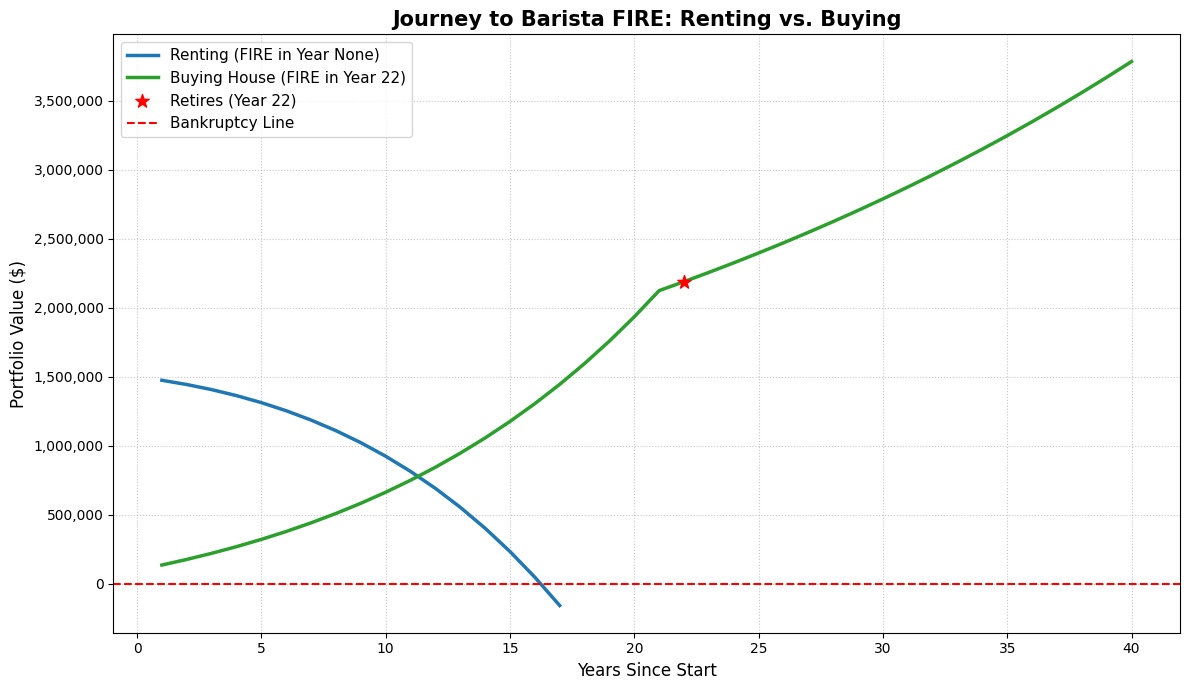

--- RESULTS ---
Renting Scenario: Can retire in Year None
Buying Scenario: Buys house in Year None, can retire in Year 22


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

def simulate_financial_lifecycle(
    max_years: int = 40,
    initial_portfolio: float = 100000.0,
    
    # Income Parameters
    full_time_salary: float = 80000.0,
    barista_salary: float = 20000.0,
    salary_growth_rate: float = 0.03,
    
    # Expense Parameters
    base_expenses: float = 40000.0,
    inflation_rate: float = 0.03,
    
    # Investment Parameters
    investment_return: float = 0.07,
    safe_withdrawal_rate: float = 0.04, # 4% rule to determine retirement readiness
    
    # Housing Parameters
    buy_house: bool = True,
    target_house_purchase_year: int = 10,
    initial_house_price: float = 6000000.0,
    down_payment_pct: float = 0.20,
    mortgage_rate: float = 0.03,
    mortgage_term: int = 30,
    initial_rent: float = 10000.0,
    property_tax_maint_pct: float = 0.015 # Real world: 1.5% of house value per year
):
    """Simulates the lifecycle from full-time work to Barista FIRE."""
    
    portfolio = initial_portfolio
    current_full_salary = full_time_salary
    current_barista_salary = barista_salary
    current_base_expenses = base_expenses
    current_rent = initial_rent
    current_house_price = initial_house_price
    
    owns_house = False
    house_purchase_year = None
    mortgage_payment_annual = 0.0
    
    is_retired = False
    retirement_year = None
    
    data = []

    for year in range(1, max_years + 1):
        # 1. Housing Logic: Try to buy the house if it's time
        if buy_house and not owns_house and year >= target_house_purchase_year:
            down_payment = current_house_price * down_payment_pct
            # Check if we can actually afford the down payment
            if portfolio >= down_payment:
                portfolio -= down_payment
                owns_house = True
                house_purchase_year = year
                
                # Calculate fixed 30-year mortgage
                loan_amount = current_house_price - down_payment
                monthly_rate = mortgage_rate / 12
                months = mortgage_term * 12
                if monthly_rate > 0:
                    monthly_mortgage = loan_amount * (monthly_rate * (1 + monthly_rate)**months) / ((1 + monthly_rate)**months - 1)
                else:
                    monthly_mortgage = loan_amount / months
                mortgage_payment_annual = monthly_mortgage * 12

        # 2. Determine Current Housing Costs
        if owns_house:
            # Still paying mortgage?
            if year < house_purchase_year + mortgage_term:
                housing_cost = mortgage_payment_annual + (current_house_price * property_tax_maint_pct)
            else:
                # Mortgage paid off! Only pay taxes and maintenance
                housing_cost = current_house_price * property_tax_maint_pct
        else:
            housing_cost = current_rent

        # 3. Check for Retirement (Barista FIRE) Readiness
        if not is_retired:
            # FIRE Target = (Total Expenses - Part-Time Income) / Safe Withdrawal Rate
            annual_shortfall = current_base_expenses + housing_cost - current_barista_salary
            fire_target = max(0, annual_shortfall / safe_withdrawal_rate)
            
            if portfolio >= fire_target:
                is_retired = True
                retirement_year = year

        # 4. Income and Cashflow Calculation
        current_income = current_barista_salary if is_retired else current_full_salary
        total_expenses = current_base_expenses + housing_cost
        net_cashflow = current_income - total_expenses
        
        # 5. Portfolio Update (Grow first, then add savings or subtract shortfall)
        portfolio *= (1 + investment_return)
        portfolio += net_cashflow
        
        # 6. Record Data
        data.append({
            "Year": year,
            "Age": 25 + year, # Assuming starting age of 25
            "Portfolio": portfolio,
            "Income": current_income,
            "Expenses": total_expenses,
            "Phase": "Barista FIRE" if is_retired else "Accumulation",
            "Owns_House": owns_house
        })
        
        # Break if bankrupt
        if portfolio < 0:
            break
            
        # 7. Apply Annual Inflation
        current_full_salary *= (1 + salary_growth_rate)
        current_barista_salary *= (1 + salary_growth_rate)
        current_base_expenses *= (1 + inflation_rate)
        current_rent *= (1 + inflation_rate)
        current_house_price *= (1 + inflation_rate)

    return pd.DataFrame(data), retirement_year, house_purchase_year

# --- RUN SIMULATIONS ---
# Scenario A: Rent forever
df_rent, retire_year_rent, _ = simulate_financial_lifecycle(
    buy_house=False,
    initial_portfolio=1500000.0,
    base_expenses=200000.0,
    barista_salary=5000
)

# Scenario B: Buy house after 5 years (Year 5)
df_buy, retire_year_buy, buy_year_actual = simulate_financial_lifecycle(
    buy_house=True, 
    target_house_purchase_year=10,
    barista_salary=5000

)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 7))

# Plot Portfolio Trajectories
plt.plot(df_rent['Year'], df_rent['Portfolio'], label=f'Renting (FIRE in Year {retire_year_rent})', color='#1f77b4', linewidth=2.5)
plt.plot(df_buy['Year'], df_buy['Portfolio'], label=f'Buying House (FIRE in Year {retire_year_buy})', color='#2ca02c', linewidth=2.5)

# Add event markers for the Buying Scenario
if buy_year_actual:
    buy_portfolio = df_buy[df_buy['Year'] == buy_year_actual]['Portfolio'].values[0]
    plt.scatter([buy_year_actual], [buy_portfolio], color='orange', s=100, zorder=5, label=f'Buys House (Year {buy_year_actual})')

if retire_year_buy:
    retire_portfolio = df_buy[df_buy['Year'] == retire_year_buy]['Portfolio'].values[0]
    plt.scatter([retire_year_buy], [retire_portfolio], color='red', s=100, zorder=5, marker='*', label=f'Retires (Year {retire_year_buy})')

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Bankruptcy Line')

# Formatting
plt.title('Journey to Barista FIRE: Renting vs. Buying', fontsize=15, fontweight='bold')
plt.xlabel('Years Since Start', fontsize=12)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()

# Print summary to console
print(f"--- RESULTS ---")
print(f"Renting Scenario: Can retire in Year {retire_year_rent}")
if retire_year_buy:
    print(f"Buying Scenario: Buys house in Year {buy_year_actual}, can retire in Year {retire_year_buy}")
else:
    print("Buying Scenario: Did not reach retirement within the timeframe.")